In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Reading the CSV file into a DataFrame
data = pd.read_csv('Scenario Data.csv')
data

,concept:name,time:timestamp,org:resource,lifecycle:transition,duration_in_s,case:concept:name,case:case_type,case:customer_group_id,case:customer_count,amount
0,Customer Group Enters,2023-04-01 11:20:00+00:00,NaN,schedule,NaN,customers_0,customers,regular_0,1.0,NaN
1,Customer Group Enters,2023-04-01 11:30:00+00:00,Restaurant Tables,start,60.0,customers_0,customers,regular_0,1.0,NaN
2,Customer Group Enters,2023-04-01 11:31:00+00:00,Restaurant Tables,complete,NaN,customers_0,customers,regular_0,1.0,NaN
3,Customer Group Occupies Table,2023-04-01 11:31:00+00:00,Restaurant Tables,start,NaN,customers_0,customers,regular_0,1.0,NaN
4,Receive Order,2023-04-01 11:31:00+00:00,Baito-san B,start,60.0,customers_0,customers,regular_0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
89944,Customer Group Pays,2023-05-16 19:08:52+00:00,Customer-san,start,60.0,customers_1500,customers,regular_1500,2.0,NaN
89945,Customer Group Pays,2023-05-16 19:09:52+00:00,Customer-san,complete,NaN,customers_1500,customers,regular_1500,2.0,1770.0
89946,Customer Group Occupies Table,2023-05-16 19:09:52+00:00,Restaurant Tables,complete,NaN,customers_1500,customers,regular_1500,2.0,NaN
89947,Customer Group Exits,2023-05-16 19:09:52+00:00,Customer-san,start,0.0,customers_1500,customers,regular_1500,2.0,NaN


In [3]:
# Distribution of org:resource
data['org:resource'].value_counts()

org:resource
Tenchou-san          26458
Customer-san         14904
Deshi-san B          11916
Deshi-san A          11740
Restaurant Tables     8108
Oku-san               6940
Baito-san B           3898
Baito-san A           3806
Kitchen                152
Name: count, dtype: int64

In [4]:
# Distribution of lifecycle:transition
data['lifecycle:transition'].value_counts()

lifecycle:transition
start       43961
complete    43961
schedule     2027
Name: count, dtype: int64

In [5]:
# Distribution of case:case_type
data['case:case_type'].value_counts()

case:case_type
customers    88189
store          924
prep           836
Name: count, dtype: int64

In [6]:
# Distribution of case:customer_group_id
data['case:customer_group_id'].value_counts()

case:customer_group_id
regular_239     83
regular_1078    83
regular_1437    83
regular_1148    83
regular_177     83
                ..
 peak_612       23
 peak_470       23
 peak_321       23
 peak_133       23
regular_1180    23
Name: count, Length: 2027, dtype: int64

In [7]:
# Distribution of case:customer:count
data['case:customer_count'].value_counts()

case:customer_count
1.0    33478
3.0    30602
2.0    24109
Name: count, dtype: int64

In [8]:
# Identifying the data types for each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89949 entries, 0 to 89948
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   concept:name            89949 non-null  object 
 1   time:timestamp          89949 non-null  object 
 2   org:resource            87922 non-null  object 
 3   lifecycle:transition    89949 non-null  object 
 4   duration_in_s           41934 non-null  float64
 5   case:concept:name       89949 non-null  object 
 6   case:case_type          89949 non-null  object 
 7   case:customer_group_id  88189 non-null  object 
 8   case:customer_count     88189 non-null  float64
 9   amount                  2027 non-null   float64
dtypes: float64(3), object(7)
memory usage: 6.9+ MB


In [9]:
# Extracting orders
receive_orders = data[(data['concept:name'] == 'Receive Order') & (data['lifecycle:transition'] == 'start')]
serve_orders = data[(data['concept:name'] == 'Serve Table Order') & (data['lifecycle:transition'] == 'complete')]

In [10]:
# Merging and calculating time
orders = pd.merge(receive_orders, serve_orders, on = 'case:concept:name', suffixes = ('_receive', '_serve'))
orders

,concept:name_receive,time:timestamp_receive,org:resource_receive,lifecycle:transition_receive,duration_in_s_receive,case:concept:name,case:case_type_receive,case:customer_group_id_receive,case:customer_count_receive,amount_receive,concept:name_serve,time:timestamp_serve,org:resource_serve,lifecycle:transition_serve,duration_in_s_serve,case:case_type_serve,case:customer_group_id_serve,case:customer_count_serve,amount_serve
0,Receive Order,2023-04-01 11:31:00+00:00,Baito-san B,start,60.0,customers_0,customers,regular_0,1.0,NaN,Serve Table Order,2023-04-01 11:38:36.666666+00:00,Baito-san A,complete,NaN,customers,regular_0,1.0,NaN
1,Receive Order,2023-04-01 11:47:00+00:00,Baito-san A,start,60.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN
2,Receive Order,2023-04-01 11:48:00+00:00,Baito-san B,start,60.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN
3,Receive Order,2023-04-01 11:49:00+00:00,Baito-san A,start,120.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN
4,Receive Order,2023-04-01 12:00:00+00:00,Oku-san,start,60.0,customers_2,customers,regular_2,1.0,NaN,Serve Table Order,2023-04-01 12:07:01.833333+00:00,Oku-san,complete,NaN,customers,regular_2,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3393,Receive Order,2023-05-16 18:42:00+00:00,Baito-san A,start,60.0,customers peak_655,customers,peak_655,1.0,NaN,Serve Table Order,2023-05-16 18:45:10+00:00,Baito-san B,complete,NaN,customers,peak_655,1.0,NaN
3394,Receive Order,2023-05-16 18:46:00+00:00,Baito-san A,start,60.0,customers peak_656,customers,peak_656,1.0,NaN,Serve Table Order,2023-05-16 18:53:52+00:00,Baito-san A,complete,NaN,customers,peak_656,1.0,NaN
3395,Receive Order,2023-05-16 18:47:00+00:00,Baito-san B,start,60.0,customers peak_657,customers,peak_657,1.0,NaN,Serve Table Order,2023-05-16 18:55:00+00:00,Oku-san,complete,NaN,customers,peak_657,1.0,NaN
3396,Receive Order,2023-05-16 18:48:00+00:00,Baito-san B,start,60.0,customers_1500,customers,regular_1500,2.0,NaN,Serve Table Order,2023-05-16 18:56:52+00:00,Baito-san A,complete,NaN,customers,regular_1500,2.0,NaN


In [11]:
# Converting time columns (string) to datetime objects for calculations
# String values are in IS08601 format
orders['time:timestamp_receive'] = pd.to_datetime(orders['time:timestamp_receive'], format = 'ISO8601')
orders['time:timestamp_serve'] = pd.to_datetime(orders['time:timestamp_serve'], format = 'ISO8601')

# Calculating processing time in minutes
orders['processing_time_min'] = (orders['time:timestamp_serve'] - orders['time:timestamp_receive']).dt.total_seconds()/60
orders

,concept:name_receive,time:timestamp_receive,org:resource_receive,lifecycle:transition_receive,duration_in_s_receive,case:concept:name,case:case_type_receive,case:customer_group_id_receive,case:customer_count_receive,amount_receive,concept:name_serve,time:timestamp_serve,org:resource_serve,lifecycle:transition_serve,duration_in_s_serve,case:case_type_serve,case:customer_group_id_serve,case:customer_count_serve,amount_serve,processing_time_min
0,Receive Order,2023-04-01 11:31:00+00:00,Baito-san B,start,60.0,customers_0,customers,regular_0,1.0,NaN,Serve Table Order,2023-04-01 11:38:36.666666+00:00,Baito-san A,complete,NaN,customers,regular_0,1.0,NaN,7.611111
1,Receive Order,2023-04-01 11:47:00+00:00,Baito-san A,start,60.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,11.166667
2,Receive Order,2023-04-01 11:48:00+00:00,Baito-san B,start,60.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,10.166667
3,Receive Order,2023-04-01 11:49:00+00:00,Baito-san A,start,120.0,customers_1,customers,regular_1,3.0,NaN,Serve Table Order,2023-04-01 11:58:10+00:00,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,9.166667
4,Receive Order,2023-04-01 12:00:00+00:00,Oku-san,start,60.0,customers_2,customers,regular_2,1.0,NaN,Serve Table Order,2023-04-01 12:07:01.833333+00:00,Oku-san,complete,NaN,customers,regular_2,1.0,NaN,7.030556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3393,Receive Order,2023-05-16 18:42:00+00:00,Baito-san A,start,60.0,customers peak_655,customers,peak_655,1.0,NaN,Serve Table Order,2023-05-16 18:45:10+00:00,Baito-san B,complete,NaN,customers,peak_655,1.0,NaN,3.166667
3394,Receive Order,2023-05-16 18:46:00+00:00,Baito-san A,start,60.0,customers peak_656,customers,peak_656,1.0,NaN,Serve Table Order,2023-05-16 18:53:52+00:00,Baito-san A,complete,NaN,customers,peak_656,1.0,NaN,7.866667
3395,Receive Order,2023-05-16 18:47:00+00:00,Baito-san B,start,60.0,customers peak_657,customers,peak_657,1.0,NaN,Serve Table Order,2023-05-16 18:55:00+00:00,Oku-san,complete,NaN,customers,peak_657,1.0,NaN,8.000000
3396,Receive Order,2023-05-16 18:48:00+00:00,Baito-san B,start,60.0,customers_1500,customers,regular_1500,2.0,NaN,Serve Table Order,2023-05-16 18:56:52+00:00,Baito-san A,complete,NaN,customers,regular_1500,2.0,NaN,8.866667


In [12]:
# Flagging peak periods and getting party size
orders['is_peak'] = orders['case:customer_group_id_receive'].str.contains('peak', na = False)
orders['party_size'] = orders['case:customer_count_receive']

orders.head()

,concept:name_receive,time:timestamp_receive,org:resource_receive,lifecycle:transition_receive,duration_in_s_receive,case:concept:name,case:case_type_receive,case:customer_group_id_receive,case:customer_count_receive,amount_receive,...,org:resource_serve,lifecycle:transition_serve,duration_in_s_serve,case:case_type_serve,case:customer_group_id_serve,case:customer_count_serve,amount_serve,processing_time_min,is_peak,party_size
0,Receive Order,2023-04-01 11:31:00+00:00,Baito-san B,start,60.0,customers_0,customers,regular_0,1.0,NaN,...,Baito-san A,complete,NaN,customers,regular_0,1.0,NaN,7.611111,False,1.0
1,Receive Order,2023-04-01 11:47:00+00:00,Baito-san A,start,60.0,customers_1,customers,regular_1,3.0,NaN,...,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,11.166667,False,3.0
2,Receive Order,2023-04-01 11:48:00+00:00,Baito-san B,start,60.0,customers_1,customers,regular_1,3.0,NaN,...,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,10.166667,False,3.0
3,Receive Order,2023-04-01 11:49:00+00:00,Baito-san A,start,120.0,customers_1,customers,regular_1,3.0,NaN,...,Baito-san B,complete,NaN,customers,regular_1,3.0,NaN,9.166667,False,3.0
4,Receive Order,2023-04-01 12:00:00+00:00,Oku-san,start,60.0,customers_2,customers,regular_2,1.0,NaN,...,Oku-san,complete,NaN,customers,regular_2,1.0,NaN,7.030556,False,1.0


In [13]:
# Calculating key metrics
# Average Order-to-Table Time
avg_time = orders['processing_time_min'].mean()
# Percentage of orders exceeding target
pct_exceeding = (orders['processing_time_min'] > 7).mean() * 100
# Peak Time
peak_time = orders[orders['is_peak']]['processing_time_min'].mean()
# Regular Time
regular_time = orders[~orders['is_peak']]['processing_time_min'].mean()
# Peak Excess
peak_excess = (orders[orders['is_peak']]['processing_time_min'] > 7).mean() * 100
# Regular Excess
regular_excess = (orders[~orders['is_peak']]['processing_time_min'] > 7).mean() * 100

In [14]:
# Printing results
print(f"Average Order-to-Table Time: {avg_time:.2f} minutes (Target: 7.00 minutes)")
print(f"Percentage of orders exceeding target: {pct_exceeding:.1f}%")
print(f"Peak periods: {peak_time:.2f} minutes ({peak_excess:.1f}% exceed target)")
print(f"Regular periods: {regular_time:.2f} minutes ({regular_excess:.1f}% exceed target)")
print(f"Peak vs regular difference: {peak_time - regular_time:.2f} minutes")

Average Order-to-Table Time: 8.88 minutes (Target: 7.00 minutes)
Percentage of orders exceeding target: 87.9%
Peak periods: 7.58 minutes (71.7% exceed target)
Regular periods: 9.16 minutes (91.4% exceed target)
Peak vs regular difference: -1.59 minutes


In [15]:
# Defining food preparation activities
food_prep_activities = [
    'Get Bowl',
    'Add Udon to Pot',
    'Add Curry to Bowl',
    'Add Rice to Bowl',
    'Strain and Wash Udon',
    'Batter Tempura',
    'Take out Tempura',
    'Add Tempura to Bowl',
]  # Add all relevant activities

# Filtering data for food preparation activities
food_prep_data = data[data['concept:name'].isin(food_prep_activities)]

# Calculating the average food preparation time
average_food_prep_time = food_prep_data['duration_in_s'].mean()
print(f'Average Food Preparation Time: {average_food_prep_time: .2f} seconds')

Average Food Preparation Time:  17.38 seconds


In [16]:
# Analyzing food prep activities individually
activity_times = food_prep_data.groupby('concept:name')['duration_in_s'].mean().sort_values(ascending = False)
activity_times

concept:name
Add Rice to Bowl        28.297980
Add Tempura to Bowl     26.428584
Strain and Wash Udon    22.401671
Take out Tempura        21.875607
Add Curry to Bowl       20.876978
Get Bowl                11.179517
Batter Tempura          10.074744
Add Udon to Pot         10.062184
Name: duration_in_s, dtype: float64

In [17]:
# Impact of party size on order prioritization
size_impact = orders.groupby('party_size')['processing_time_min'].mean().dropna()
size_impact

party_size
1.0    7.525562
2.0    8.900479
3.0    9.985621
Name: processing_time_min, dtype: float64

In [18]:
# Calculating percentage of orders that exceed 7-minute target time for specific party size
for size, time in size_impact.items():
    # Filter the orders DataFrame to include only orders for specific party size
    # Create a boolean series where each value is True if the processing time is greater than 7 minutes, else False
    # Mean of boolean series - True values are treated as 1 and False as 0, so proportion of True values calculated
    exceed = (orders[orders['party_size'] == size]['processing_time_min'] > 7).mean() * 100
    print(f"Party size {int(size)}: {time:.2f} minutes ({exceed:.1f}% exceed target)")
    
# Calculating the difference between the max and min times
max_diff = size_impact.max() - size_impact.min()
print(f"Max difference between party sizes: {max_diff:.2f} minutes")

Party size 1: 7.53 minutes (70.8% exceed target)
Party size 2: 8.90 minutes (92.7% exceed target)
Party size 3: 9.99 minutes (98.5% exceed target)
Max difference between party sizes: 2.46 minutes


In [19]:
# Analyzing prep activities
prep_df = data[data['case:case_type'] == 'prep']
# Convert seconds to minutes
prep_times = prep_df.groupby('case:concept:name')['duration_in_s'].sum() / 60

In [20]:
# Calculating key metrics
# Preparation Average
prep_avg = prep_times.mean()
# Preparation Standard Deviation
prep_std = prep_times.std()
# Preparation Coefficient of Variation
cv = (prep_std / prep_avg) * 100

In [21]:
# Printing results
print(f"Number of preparation sessions: {len(prep_times)}")
print(f"Standard deviation: {prep_std:.2f} minutes")
print(f"Coefficient of variation: {cv:.1f}%")

Number of preparation sessions: 38
Standard deviation: 11.24 minutes
Coefficient of variation: 2.0%


In [22]:
# Calculating total time spent by each resource
time_per_resource = (data.groupby('org:resource')['duration_in_s'].sum().sort_values(ascending = False))

# Calculating the total available time
total_available_time = pd.to_datetime(data['time:timestamp'].max()) - pd.to_datetime(data['time:timestamp'].min())
total_available_time_seconds = total_available_time.total_seconds()

# Calculating percentage of time spent
time_per_resource_percentage = (time_per_resource / total_available_time_seconds) * 100

# Printing percentages
print('Percentage of time spent per resource:')
for resource, percentage in time_per_resource_percentage.items():
    print(f'{resource}: {percentage:.2f}%')

Percentage of time spent per resource:
Customer-san: 53.47%
Kitchen: 15.72%
Tenchou-san: 15.27%
Oku-san: 10.74%
Baito-san A: 4.66%
Baito-san B: 4.56%
Deshi-san B: 4.34%
Deshi-san A: 4.29%
Restaurant Tables: 3.85%


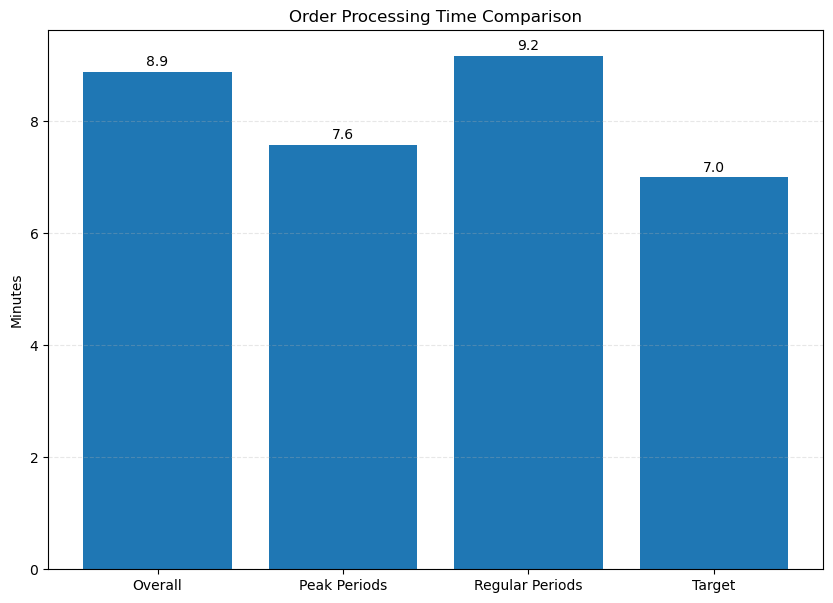

In [23]:
# Bar chart comparing order process times
plt.figure(figsize = (10, 7))
metrics = ['Overall', 'Peak Periods', 'Regular Periods', 'Target']
values = [avg_time, peak_time, regular_time, 7]

plt.bar(metrics, values)
plt.title('Order Processing Time Comparison')
plt.ylabel('Minutes')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.3)

for i, v in enumerate(values):
    plt.text(i, v + 0.1, f"{v:.1f}", ha = 'center')

plt.savefig('metrics_comparison.png')

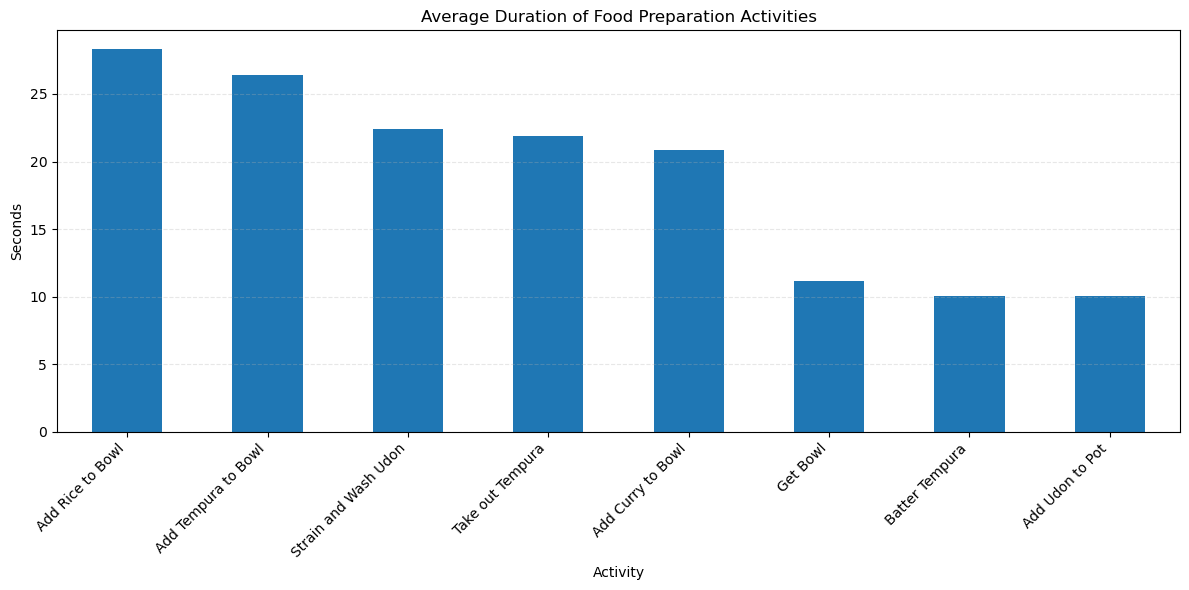

In [24]:
# Food preparation activity breakdown
plt.figure(figsize = (12, 6))

activity_times.plot(kind = 'bar')

plt.title('Average Duration of Food Preparation Activities')
plt.xlabel('Activity')
plt.ylabel('Seconds')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.grid(axis = 'y', linestyle = '--', alpha = 0.3)
plt.savefig('food_prep_activities.png')